<a href="https://colab.research.google.com/github/amber1714/ML-Case-Studies/blob/main/04_El_Nino_La_Nina/ENSO_ML_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [23]:
from google.colab import files

uploaded = files.upload()

Saving ENSO_NOAA_ONI_1950_2026.csv to ENSO_NOAA_ONI_1950_2026 (2).csv


In [24]:
df = pd.read_csv("ENSO_NOAA_ONI_1950_2026.csv")
df.head()

,Year,Season,ONI,Season_Number,ENSO_Class,ONI_Lag1,ONI_Lag2,ONI_Lag3,ONI_Rolling3_Previous
0,1950,DJF,-1.3,1,La Nina,NaN,NaN,NaN,NaN
1,1950,JFM,-1.2,2,La Nina,-1.3,NaN,NaN,NaN
2,1950,FMA,-1.1,3,La Nina,-1.2,-1.3,NaN,NaN
3,1950,MAM,-1.1,4,La Nina,-1.1,-1.2,-1.3,-1.200000
4,1950,AMJ,-1.1,5,La Nina,-1.1,-1.1,-1.2,-1.133333


In [25]:
print(df.shape)
print(df.columns.tolist())
df.info()

(919, 9)
['Year', 'Season', 'ONI', 'Season_Number', 'ENSO_Class', 'ONI_Lag1', 'ONI_Lag2', 'ONI_Lag3', 'ONI_Rolling3_Previous']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   919 non-null    int64  
 1   Season                 919 non-null    object 
 2   ONI                    919 non-null    float64
 3   Season_Number          919 non-null    int64  
 4   ENSO_Class             919 non-null    object 
 5   ONI_Lag1               918 non-null    float64
 6   ONI_Lag2               917 non-null    float64
 7   ONI_Lag3               916 non-null    float64
 8   ONI_Rolling3_Previous  916 non-null    float64
dtypes: float64(5), int64(2), object(2)
memory usage: 64.7+ KB


In [26]:
df["ENSO_Class"].value_counts()

,count
ENSO_Class,
Neutral,412
La Nina,254
El Nino,253


In [27]:
features = [
    "Season_Number",
    "ONI_Lag1",
    "ONI_Lag2",
    "ONI_Lag3",
    "ONI_Rolling3_Previous"
]

model_df = df.dropna(subset=features + ["ENSO_Class"]).copy()

train_df = model_df[model_df["Year"] < 2015]
test_df = model_df[model_df["Year"] >= 2015]

X_train = train_df[features]
y_train = train_df["ENSO_Class"]

X_test = test_df[features]
y_test = test_df["ENSO_Class"]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 777
Testing samples: 139


In [28]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8561151079136691

Classification Report:

              precision    recall  f1-score   support

     El Nino       0.94      0.90      0.92        49
     La Nina       0.84      0.84      0.84        37
     Neutral       0.80      0.83      0.81        53

    accuracy                           0.86       139
   macro avg       0.86      0.86      0.86       139
weighted avg       0.86      0.86      0.86       139



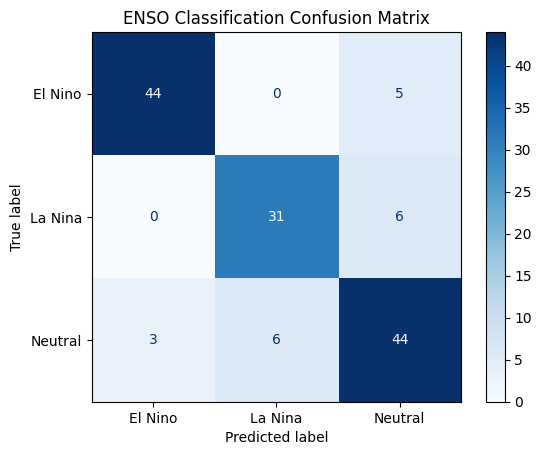

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("ENSO Classification Confusion Matrix")
plt.show()

In [32]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
1,ONI_Lag1,0.446147
4,ONI_Rolling3_Previous,0.226567
2,ONI_Lag2,0.161157
3,ONI_Lag3,0.110938
0,Season_Number,0.055191


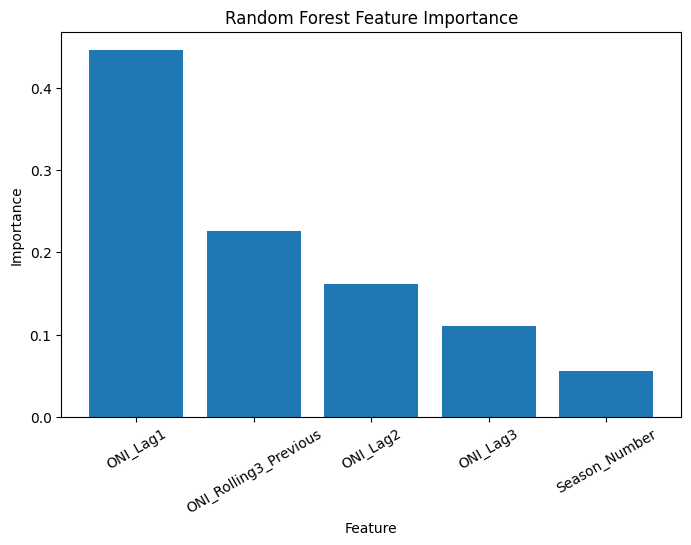

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=30)
plt.show()